In [65]:
# Imports
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import duckdb
import numpy as np

sns.set_theme(style="whitegrid")

conn = duckdb.connect("../data/duckdb.mimic")
admissions_df = conn.execute("SELECT * FROM admissions WHERE deathtime IS NULL;").df()
patients_df = conn.execute("SELECT subject_id, gender, anchor_age AS age FROM patients;").df()

patient_admissions = admissions_df.merge(patients_df, on="subject_id")
patient_admissions.info()

<class 'pandas.DataFrame'>
RangeIndex: 260 entries, 0 to 259
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   subject_id            260 non-null    int64         
 1   hadm_id               260 non-null    int64         
 2   admittime             260 non-null    datetime64[us]
 3   dischtime             260 non-null    datetime64[us]
 4   deathtime             0 non-null      datetime64[us]
 5   admission_type        260 non-null    str           
 6   admit_provider_id     260 non-null    str           
 7   admission_location    260 non-null    str           
 8   discharge_location    218 non-null    str           
 9   insurance             260 non-null    str           
 10  language              260 non-null    str           
 11  marital_status        249 non-null    str           
 12  race                  260 non-null    str           
 13  edregtime             174 non-n

# Exploratory Data Analysis - MIMIC-IV Demo
**Project:** 30-Day Hospital Readmission Risk Predictor \
**Dataset:** [MIMIC-IV Demo v2.2](https://physionet.org/content/mimic-iv-demo/2.2/) (PhysioNet)

## Overview
This notebook explores the MIMIC-IV Demo dataset to understand the structure, distributions, and quality of the clinical data before modeling. The goal is to:
 
- Understand the schema and relationships between key tables
- Characterize the study cohort (demographics, admission patterns)
- Identify data quality issues (missingness, outliers, skew)
- Surface early signals of features likely predictive of 30-day readmission
  
MIMIC-IV (Medical Information Mart for Intensive Care) is a large, de-identified database of ICU patients admitted to Beth Israel Deaconess Medical Center in Boston. The demo subset contains data for approximately 100 patients and mirrors the full dataset's schema exactly, making it ideal for pipeline development.


## 1. Finding Readmissions
To construct our outcome label, we find patients who were readmitted to the hospital within 30 days of discharge and exclude all in-hospital deaths as these patients cannot be readmitted. \
The readmission rate gives a sense of class balance before modeling. 

In [66]:
patient_admissions["admittime"] = pd.to_datetime(patient_admissions["admittime"])
patient_admissions["dischtime"] = pd.to_datetime(patient_admissions["dischtime"])

df = patient_admissions.sort_values("admittime")

first_admission = df.groupby("subject_id").first().reset_index()

def was_readmitted(row):
    subsequent = patient_admissions[
        (patient_admissions["subject_id"] == row["subject_id"]) & 
        (patient_admissions["admittime"] > row["dischtime"]) & 
        (patient_admissions["admittime"] <= patient_admissions["dischtime"] + pd.Timedelta(days=30))
    ]
    return int(len(subsequent) > 0)

df["readmitted_30d"] = df.apply(was_readmitted, axis=1)

rate = df["readmitted_30d"].sum() / len(df)
print(f"Readmission rate: {rate}")

Readmission rate: 0.6346153846153846


## Observations
- The readmission rate for this dataset is **~63.5%**, which is significantly higher than the average hospital admission rate in the original MIMIC-IV dataset of 18-23%.
- Maybe class imbalance handling is still worth considering so it generalizes well to the real dataset?
- Modeling results should be interpreted as proof-of-concept, not clinically meaningful predictions.

## 2. Age Distribution
Examine the age distribution of patients, and whether age is correlated with readmission risk.

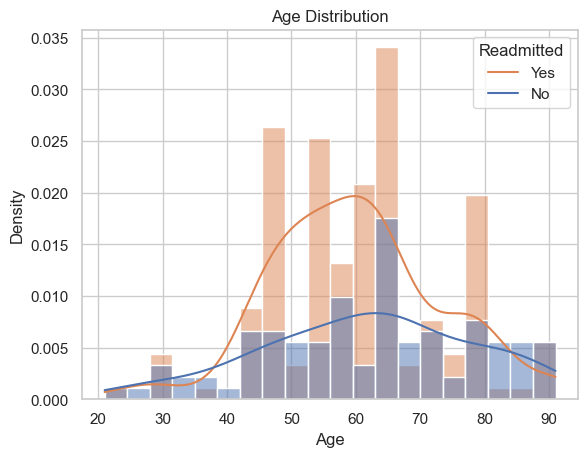

In [67]:
sns.histplot(data=df, x='age', bins=20, stat='density', kde=True, hue='readmitted_30d')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend(title='Readmitted', labels=["Yes", "No"])
plt.show()

## Observations
- Readmitted patients (orange) skew younger, peaking around 65 years old. Non-readmitted patients (blue) are more evenly distributed.
- Both groups are largely absent below 45 years old.
- The gap between the two distributions may suggest a predictive signal.

## 3. Length of Stay
Find the duration of the hospital stay in days, and examine the distribution. 

In [68]:
df['los_days'] = round((df['dischtime'] - df['admittime']).dt.total_seconds() / 86400, 2)
df['los_days'].describe()

count    260.000000
mean       6.642346
std        6.512204
min        0.050000
25%        2.612500
50%        4.720000
75%        8.297500
max       44.930000
Name: los_days, dtype: float64

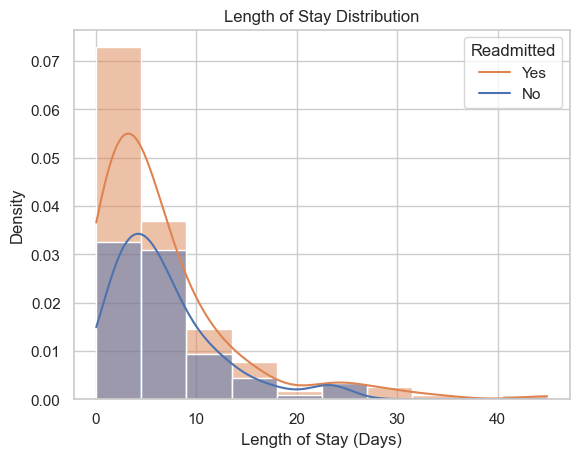

In [69]:
sns.histplot(data=df, x='los_days', stat='density', kde=True, bins=10, hue='readmitted_30d')
plt.title('Length of Stay Distribution')
plt.xlabel('Length of Stay (Days)')
plt.ylabel('Density')
plt.legend(title='Readmitted', labels=["Yes", "No"])
plt.show()

## Observations
- LoS is strongly right skewed with the majority of patients discharged within 5 days.
- Readmitted patients (orange) surprisingly show a shorter length of stay on average, which may be an indication of premature discharge.
- Extended stays do not look to be a strong predictive signal for readmission.
- Given this skew, it may be worth exploring log-transforming `los_days` during feature engineering.

## 4. Gender Readmission Rate
Examine whether the readmission rate between genders differ. Gender should be included as a predictive feature, but also as an attribute for fairness evaluation. 

In [70]:
gender_rates = df.groupby('gender')['readmitted_30d'].agg(["mean", "size"]).reset_index()
gender_rates.head()

,gender,mean,size
0,F,0.676923,130
1,M,0.592308,130


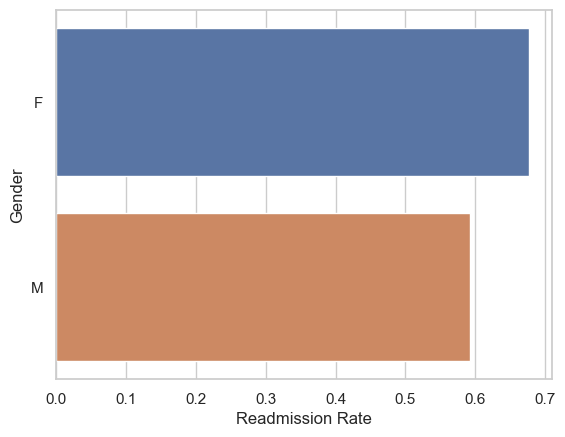

In [71]:
sns.barplot(data=gender_rates, x='mean', y='gender', hue='gender')
plt.xlabel('Readmission Rate')
plt.ylabel('Gender')
plt.show()

## Observations
- Female readmission rates (blue) are higher than male readmission rates (orange) by about 10%.
- This gap is modest, but worth taking into account.
- No causal claims should be made from this distribution.

## 5. Readmission Rate by Insurance
Insurance is potentially both a predictive signal and a proxy for socioeconomic status. Examine if readmission rate varies across insurance categories.

In [72]:
insurance_rates = df.groupby('insurance')['readmitted_30d'].agg(['mean', 'size']).reset_index().sort_values('mean', ascending=False)
insurance_rates

,insurance,mean,size
1,Medicare,0.652632,95
2,Other,0.627586,145
0,Medicaid,0.600000,20


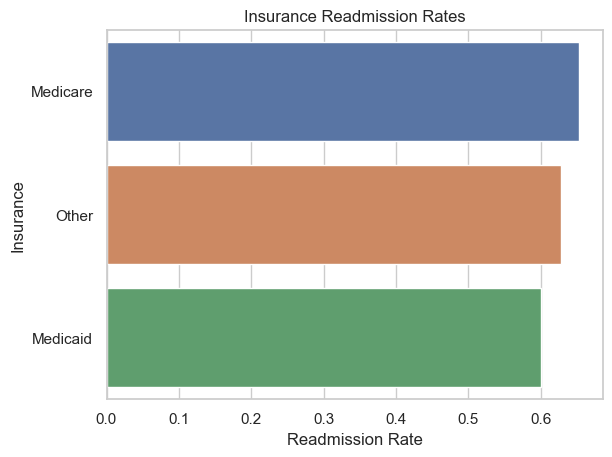

In [73]:
sns.barplot(data=insurance_rates, x='mean', y='insurance', hue='insurance')
plt.title('Insurance Readmission Rates')
plt.xlabel('Readmission Rate')
plt.ylabel('Insurance')
plt.show()

## Observations
- The narrow spread across insurance types (~5%) suggests insurance alone may not be a strong standalone predictor.

## 6. Admission Type
Admission type captures the urgency and context of the initial hospitalization. Emergency admissions represent unplanned, acute events while elective admissions are scheduled procedures. We would expect emergency admissions to carry higher readmission risk given the acute nature of the underlying condition.

In [74]:
type_rates = df.groupby('admission_type')['readmitted_30d'].agg(['mean', 'size']).sort_values('mean', ascending=False).reset_index()
type_rates

,admission_type,mean,size
0,AMBULATORY OBSERVATION,1.000000,5
1,EU OBSERVATION,0.800000,30
2,DIRECT OBSERVATION,0.714286,7
3,OBSERVATION ADMIT,0.690476,42
4,DIRECT EMER.,0.642857,14
5,EW EMER.,0.632653,98
6,ELECTIVE,0.538462,13
7,URGENT,0.515152,33
8,SURGICAL SAME DAY ADMISSION,0.388889,18


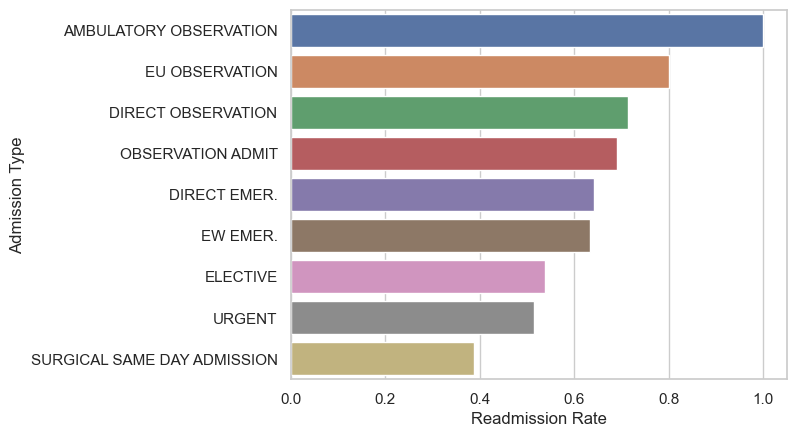

In [75]:
sns.barplot(data=type_rates, x='mean', y='admission_type', hue='admission_type')
plt.xlabel('Readmission Rate')
plt.ylabel('Admission Type')
plt.show()

## Observations
- Ambulatory Observation has a readmission rate of 100%; however, it makes up a small part of the dataset with 5 rows.
- Observation-based admissions seem to have the highest readmission rates, which could indicate that they are prematurely discharged.
- Emergency variants also make up a large portion of readmitted patients, which is expected.
- During feature engineering, we could consolidate these 9 categories into 4 buckets: Emergency, Observation, Elective, and Surgical.

## 7. Diagnosis Count
The number of ICD diagnosis codes assigned at discharge is a signal for comorbidity burden. Patients with more diagnoses are generally sicker and more complex. I expect higher diagnosis counts to correlate with higher readmission risk.

In [76]:
diagnoses = conn.execute('SELECT * FROM diagnoses_icd').df()

diagnosis_counts = diagnoses.groupby('hadm_id')['icd_code'].count().reset_index().rename(columns={'icd_code': 'n_diagnoses'})
diagnosis_counts
df = df.merge(diagnosis_counts, on='hadm_id', how='left')

df['n_diagnoses'] = df['n_diagnoses'].fillna(0)

df.head()

,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,...,marital_status,race,edregtime,edouttime,hospital_expire_flag,gender,age,readmitted_30d,los_days,n_diagnoses
0,10001725,25563031,2110-04-11 15:08:00,2110-04-14 15:00:00,NaT,EW EMER.,P35SU0,PACU,HOME,Other,...,MARRIED,WHITE,NaT,NaT,0,F,46,0,2.99,18
1,10008454,20291550,2110-11-30 06:31:00,2110-12-10 15:53:00,NaT,EW EMER.,P77BSD,EMERGENCY ROOM,HOME HEALTH CARE,Other,...,SINGLE,WHITE,2110-11-30 04:45:00,2110-11-30 08:03:00,0,F,26,0,10.39,11
2,10004422,21255400,2111-01-15 14:55:00,2111-01-25 15:00:00,NaT,EW EMER.,P1037P,PROCEDURE SITE,HOME HEALTH CARE,Medicare,...,WIDOWED,WHITE,NaT,NaT,0,M,78,0,10.00,16
3,10035631,29462354,2112-09-17 19:13:00,2112-10-17 01:41:00,NaT,DIRECT EMER.,P45GUA,PHYSICIAN REFERRAL,HOME,Other,...,MARRIED,UNKNOWN,2112-09-17 18:46:00,2112-09-17 19:50:00,0,M,63,1,29.27,18
4,10035631,24912093,2112-10-22 00:00:00,2112-10-28 12:16:00,NaT,ELECTIVE,P45GUA,PHYSICIAN REFERRAL,HOME HEALTH CARE,Other,...,MARRIED,UNKNOWN,NaT,NaT,0,M,63,1,6.51,5


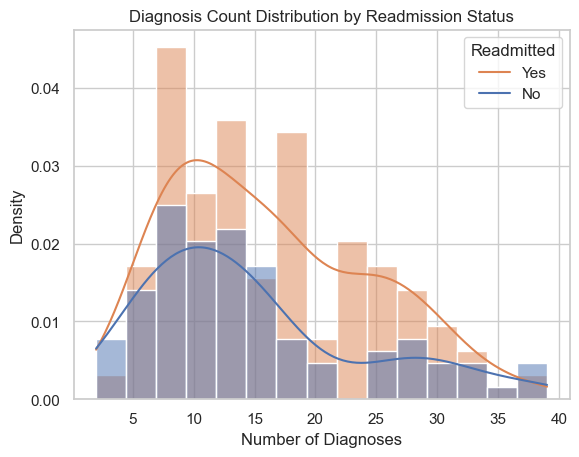

In [77]:
sns.histplot(data=df, x='n_diagnoses', hue='readmitted_30d', bins=15, kde=True, stat='density')
plt.title('Diagnosis Count Distribution by Readmission Status')
plt.legend(title='Readmitted', labels=['Yes', 'No'])
plt.xlabel('Number of Diagnoses')
plt.ylabel('Density')
plt.show()

## Observations
- Readmitted patients (orange) have a notably higher diagnosis count, peaking at 8-10 and maintaining a right tail until 40. Non-readmitted patients (blue) also peak at 8-10, but drop off more steeply.
- Clearest separation observed between the two groups, so this seems to be one of the strongest predictors across features so far.
- May benefit from log-transformation due to the distributions right-skew.

## 8. Lab Values
Lab results could be strong predictors of patient deterioration, and therefore, a strong signal for readmission risk. 

In [78]:
lab_events = conn.execute('SELECT * FROM labevents;').df()

ITEM_IDS = {
    50912: "creatinine",
    50931: "glucose",
    51222: "hemoglobin",
    50983: "sodium",
    50971: "potassium",
    51301: "wbc",
}

labs = lab_events[lab_events['itemid'].isin(ITEM_IDS.keys())]
labs['lab_name'] = labs['itemid'].map(ITEM_IDS)
labs["charttime"] = pd.to_datetime(labs["charttime"])

labs = (
    labs.sort_values("charttime")
    .groupby(["hadm_id", "lab_name"])["valuenum"]
    .last()
    .reset_index()
)

labs_pivot = labs.pivot_table(index='hadm_id', columns=['lab_name'], values='valuenum').reset_index()

df = df.merge(labs_pivot, on='hadm_id', how='left')
df.head()

,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,...,age,readmitted_30d,los_days,n_diagnoses,creatinine,glucose,hemoglobin,potassium,sodium,wbc
0,10001725,25563031,2110-04-11 15:08:00,2110-04-14 15:00:00,NaT,EW EMER.,P35SU0,PACU,HOME,Other,...,46,0,2.99,18,0.9,124.0,12.0,3.7,140.0,11.1
1,10008454,20291550,2110-11-30 06:31:00,2110-12-10 15:53:00,NaT,EW EMER.,P77BSD,EMERGENCY ROOM,HOME HEALTH CARE,Other,...,26,0,10.39,11,0.5,200.0,10.6,3.8,138.0,13.2
2,10004422,21255400,2111-01-15 14:55:00,2111-01-25 15:00:00,NaT,EW EMER.,P1037P,PROCEDURE SITE,HOME HEALTH CARE,Medicare,...,78,0,10.00,16,0.7,95.0,11.3,4.2,138.0,9.8
3,10035631,29462354,2112-09-17 19:13:00,2112-10-17 01:41:00,NaT,DIRECT EMER.,P45GUA,PHYSICIAN REFERRAL,HOME,Other,...,63,1,29.27,18,0.8,109.0,11.2,4.8,137.0,4.5
4,10035631,24912093,2112-10-22 00:00:00,2112-10-28 12:16:00,NaT,ELECTIVE,P45GUA,PHYSICIAN REFERRAL,HOME HEALTH CARE,Other,...,63,1,6.51,5,0.6,135.0,8.4,3.9,138.0,2.6


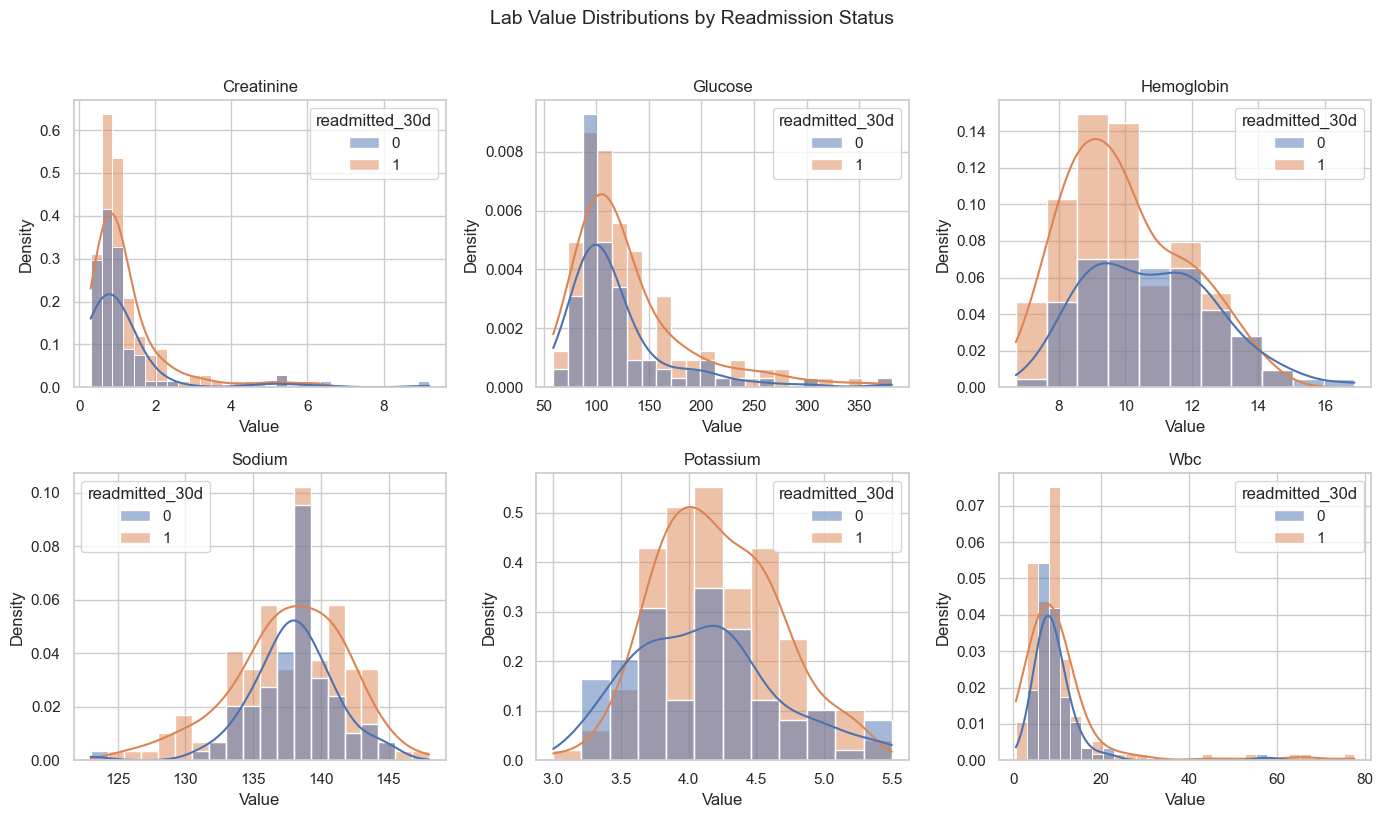

In [79]:
lab_names = list(ITEM_IDS.values())

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, lab in enumerate(lab_names):
    sns.histplot(data=df, x=lab, hue='readmitted_30d', kde=True, stat='density', ax=axes[i])
    axes[i].set_title(lab.capitalize())
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Density')

plt.suptitle("Lab Value Distributions by Readmission Status", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

## Observations
- Glucose and white blood cell count right tails seem to be good predictors for readmission.
- Low hemoglobin also seems to be a strong predictor.
- All counts will be most likely be included as features.

## 9. Prescription Type and Count
The number of unique prescriptions given during admission can signal complications and comorbidity burden, both of which can possibly predcit readmission. Also, I want to flag the presence of high-risk medications (such as anticoagulants, insulin, etc.).

In [80]:
prescriptions = conn.execute('SELECT * FROM prescriptions;').df()
prescriptions.head()

rx_counts = prescriptions.groupby('hadm_id')['drug'].nunique().reset_index().rename(columns={'drug': 'n_drugs'})
df = df.merge(rx_counts, on='hadm_id', how='left')

df.head()

,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,...,readmitted_30d,los_days,n_diagnoses,creatinine,glucose,hemoglobin,potassium,sodium,wbc,n_drugs
0,10001725,25563031,2110-04-11 15:08:00,2110-04-14 15:00:00,NaT,EW EMER.,P35SU0,PACU,HOME,Other,...,0,2.99,18,0.9,124.0,12.0,3.7,140.0,11.1,35.0
1,10008454,20291550,2110-11-30 06:31:00,2110-12-10 15:53:00,NaT,EW EMER.,P77BSD,EMERGENCY ROOM,HOME HEALTH CARE,Other,...,0,10.39,11,0.5,200.0,10.6,3.8,138.0,13.2,39.0
2,10004422,21255400,2111-01-15 14:55:00,2111-01-25 15:00:00,NaT,EW EMER.,P1037P,PROCEDURE SITE,HOME HEALTH CARE,Medicare,...,0,10.00,16,0.7,95.0,11.3,4.2,138.0,9.8,65.0
3,10035631,29462354,2112-09-17 19:13:00,2112-10-17 01:41:00,NaT,DIRECT EMER.,P45GUA,PHYSICIAN REFERRAL,HOME,Other,...,1,29.27,18,0.8,109.0,11.2,4.8,137.0,4.5,40.0
4,10035631,24912093,2112-10-22 00:00:00,2112-10-28 12:16:00,NaT,ELECTIVE,P45GUA,PHYSICIAN REFERRAL,HOME HEALTH CARE,Other,...,1,6.51,5,0.6,135.0,8.4,3.9,138.0,2.6,16.0


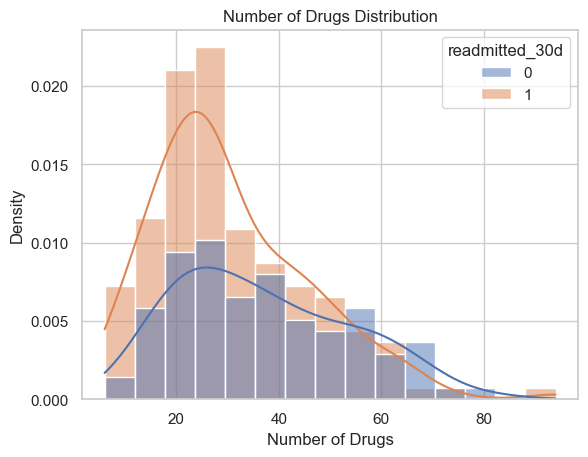

In [81]:
sns.histplot(data=df, x='n_drugs', bins=15, hue='readmitted_30d', stat='density', kde=True)
plt.title('Number of Drugs Distribution')
plt.xlabel('Number of Drugs')
plt.ylabel('Density')
plt.show()

In [84]:
HIGH_RISK_DRUGS = [
    "warfarin", "apixaban", "rivaroxaban", "heparin", "insulin", "metformin", "lorazepam", "clonazepam",
    "digoxin", "lithium", "vancomycin", "methotrexate", "fentanyl", "morphine", "doxorubicin", "furosemide",
    "amoxicillin"
]

pattern = "|".join(HIGH_RISK_DRUGS)
prescriptions["is_high_risk"] = (
    prescriptions["drug"].str.lower().str.contains(pattern, na=False)
)

print(f"Patients with high-risk rx: {df['high_risk_drug'].sum()}")

high_risk_flag = (
    prescriptions.groupby("hadm_id")["is_high_risk"]
    .any()
    .astype(int)
    .reset_index()
    .rename(columns={"is_high_risk": "high_risk_drug"})
)

df = df.merge(high_risk_flag, on='hadm_id', how='left')

df.head()

Patients with high-risk rx: 224.0


,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,...,n_diagnoses,creatinine,glucose,hemoglobin,potassium,sodium,wbc,n_drugs,high_risk_drug_x,high_risk_drug_y
0,10001725,25563031,2110-04-11 15:08:00,2110-04-14 15:00:00,NaT,EW EMER.,P35SU0,PACU,HOME,Other,...,18,0.9,124.0,12.0,3.7,140.0,11.1,35.0,1.0,1.0
1,10008454,20291550,2110-11-30 06:31:00,2110-12-10 15:53:00,NaT,EW EMER.,P77BSD,EMERGENCY ROOM,HOME HEALTH CARE,Other,...,11,0.5,200.0,10.6,3.8,138.0,13.2,39.0,1.0,1.0
2,10004422,21255400,2111-01-15 14:55:00,2111-01-25 15:00:00,NaT,EW EMER.,P1037P,PROCEDURE SITE,HOME HEALTH CARE,Medicare,...,16,0.7,95.0,11.3,4.2,138.0,9.8,65.0,1.0,1.0
3,10035631,29462354,2112-09-17 19:13:00,2112-10-17 01:41:00,NaT,DIRECT EMER.,P45GUA,PHYSICIAN REFERRAL,HOME,Other,...,18,0.8,109.0,11.2,4.8,137.0,4.5,40.0,1.0,1.0
4,10035631,24912093,2112-10-22 00:00:00,2112-10-28 12:16:00,NaT,ELECTIVE,P45GUA,PHYSICIAN REFERRAL,HOME HEALTH CARE,Other,...,5,0.6,135.0,8.4,3.9,138.0,2.6,16.0,1.0,1.0


<Axes: xlabel='readmitted_30d', ylabel='high_risk_drug'>

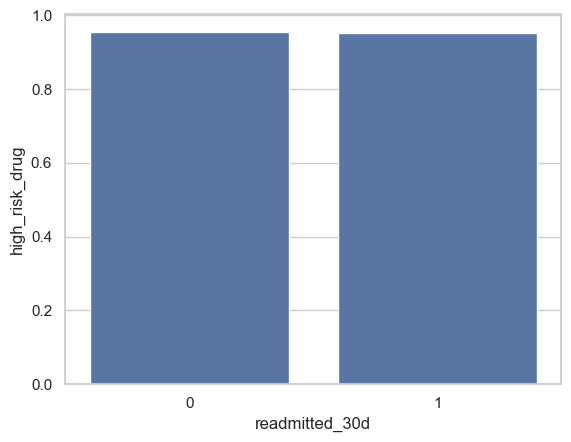

In [83]:
high_risk_rates = (
    df.groupby("readmitted_30d")["high_risk_drug"]
    .mean()
    .reset_index()
)

sns.barplot(
    data=high_risk_rates, x="readmitted_30d", y="high_risk_drug",
)

## Observations
- Readmitted patients peak at 20-25 unique medications while non-readmitted patients show a flatter, wider distribution extending to 90+ drugs.
- The binary high-risk drug flag was dropped as a feature — ~95% of patients in both groups had at least one high-risk drug, making it non-discriminative in an ICU setting where these medications are standard of care.

## 10. Procedure Distribution
The number and type of procedures performed during admission could be a signal for readmission. I probably want procedure count as a feature and one hot encode the type of procedures for each patient.

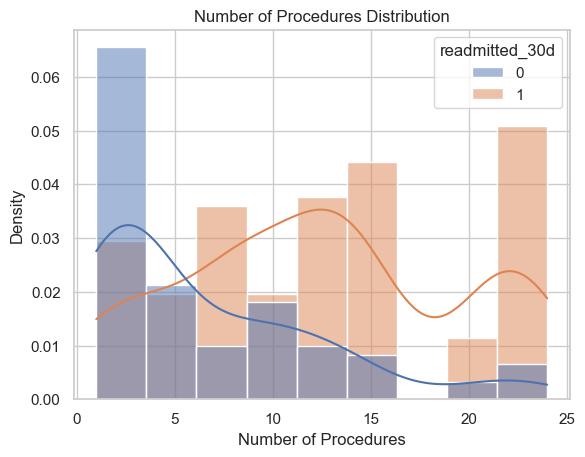

In [91]:
procedures = conn.execute('SELECT * FROM procedures_icd;').df()
procedure_codes = conn.execute('SELECT * FROM d_icd_procedures').df()

procedures = procedures.merge(procedure_codes[['icd_code', 'long_title']], on='icd_code', how='left')
procedure_counts = procedures.groupby('subject_id')['long_title'].nunique().reset_index().rename(columns={'long_title': 'n_procedures'})

df = df.merge(procedure_counts, on='subject_id', how='left')

sns.histplot(data=df, x='n_procedures', hue='readmitted_30d', kde=True, stat='density')
plt.title('Number of Procedures Distribution')
plt.xlabel('Number of Procedures')
plt.ylabel('Density')
plt.show()

## Observations
- Procedure count shows the strongest separation between the two groups.
- Non-readmitted patients (blue) hover around 0-3 procedures, while readmitted patients (orange) show a much more right-shifted distribution.
- Clear relationship with outcome variable.

## 11. Correlation Matrix
Find the correlation coefficient for prospective features.

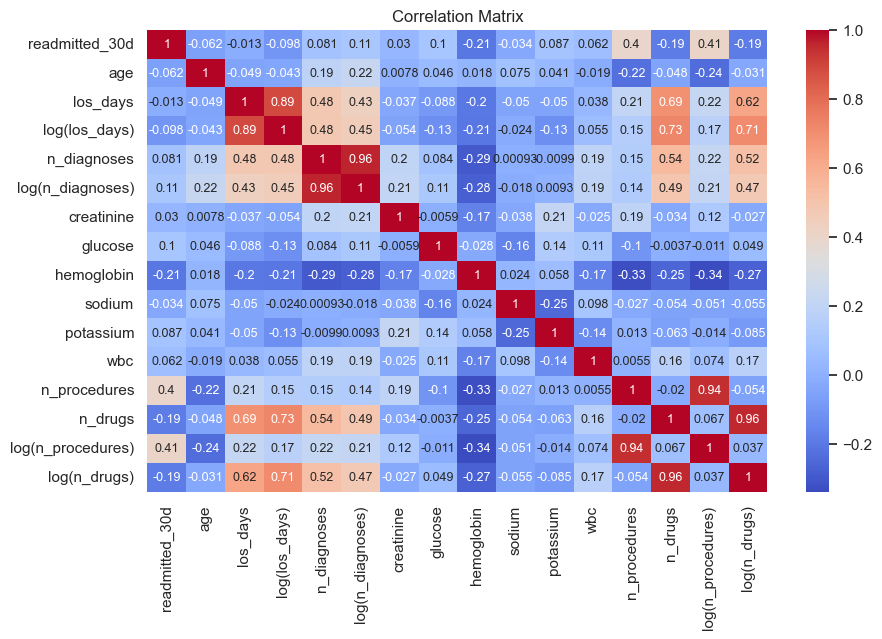

In [97]:
df['log(los_days)'] = np.log1p(df['los_days'])
df['log(n_diagnoses)'] = np.log1p(df['n_diagnoses'])
df['log(n_drugs)'] = np.log1p(df['n_drugs'])
df['log(n_procedures)'] = np.log1p(df['n_procedures'])

features = ['readmitted_30d', 'age', 'los_days', 'log(los_days)', 'n_diagnoses', 'log(n_diagnoses)',
            'creatinine', 'glucose', 'hemoglobin', 'sodium', 'potassium', 'wbc', 'n_procedures', 'n_drugs',
           'log(n_procedures)', 'log(n_drugs)']

plt.figure(figsize=(10, 6))
sns.heatmap(data=df[features].corr(), cmap='coolwarm', annot=True, annot_kws={'size': 9})
plt.title('Correlation Matrix')
plt.show()

## Observations
- Individual feature correlations are weak.
- Strongest signal is coming from `log(n_procedures)` with a correlation coefficient of .41
- `hemoglobin`, `log(n_diagnoses)`, and `log(n_drugs)` seem to be decent signals for readmission as well.
- To avoid issues with multicollinearity, only log-transformed features will be carried into the model.
- Final feature set looks to be: `log(los_days)`, `log(n_diagnoses)`, `log(n_procedures)`, `log(n_drugs)`, `age`, `hemoglobin`, `creatinine`, `glucose`, `sodium`, `potassium`, `wbc`, and `gender`.